In [1]:
import requests
import pandas as pd
import json
from datetime import datetime, timedelta

In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
API_KEY = "8b888742a5f6eba30abcb10db08b5881"
BASE    = "https://api.stlouisfed.org/fred/series/observations"
START   = "2015-01-01"   # enough history for YoY + trends

In [3]:
# ── SERIES MAP ────────────────────────────────────────────────────────────────
# category -> { label: series_id }
SERIES = {
    "rent_pressure": {
        "rent_cpi":        "CUSR0000SEHA",   # Rent of primary residence CPI
        "shelter_cpi":     "CUSR0000SAH1",   # Shelter CPI
        "mortgage_rate":   "MORTGAGE30US",   # 30-yr fixed mortgage rate
        "fed_funds_rate":  "FEDFUNDS",       # Federal funds rate
        "real_wages":      "AHETPI",         # Avg hourly earnings (proxy)
        "housing_price":   "CSUSHPISA",      # Case-Shiller home price index
    },
    "job_market": {
        "unemployment":    "UNRATE",         # Unemployment rate
        "job_openings":    "JTSJOL",         # Job openings (JOLTS)
        "initial_claims":  "ICSA",           # Initial jobless claims
        "labor_force_part":"CIVPART",        # Labor force participation rate
        "real_wage_growth":"CES0500000003",  # Avg hourly earnings, all private
    },
    "inflation_pressure": {
        "cpi_all":         "CPIAUCSL",       # CPI all items
        "core_cpi":        "CPILFESL",       # Core CPI (ex food & energy)
        "food_cpi":        "CPIUFDSL",       # Food CPI
        "energy_cpi":      "CPIENGSL",       # Energy CPI
        "gas_prices":      "GASREGCOVW",     # Regular gasoline retail prices
    },
    "borrowing_pressure": {
        "fed_funds_rate":  "FEDFUNDS",
        "credit_card_rate":"TERMCBCCALLNS",  # Credit card interest rate
        "mortgage_rate":   "MORTGAGE30US",
    },
    "wage_strength": {
        "avg_hourly_earn": "CES0500000003",  # Avg hourly earnings, all private
        "real_hourly_earn":"CES0500000011",  # Real avg hourly earnings
        "cpi_inflation":   "CPIAUCSL",
    },
    "consumer_sentiment": {
        "umich_sentiment": "UMCSENT",        # U of Michigan consumer sentiment
    },
}

In [ ]:
# ── FETCH ─────────────────────────────────────────────────────────────────────
def fetch_series(series_id: str) -> pd.Series:
    """Pull a single FRED series, return a dated pd.Series."""
    params = {
        "series_id":      series_id,
        "api_key":        API_KEY,
        "file_type":      "json",
        "observation_start": START,
    }
    r = requests.get(BASE, params=params)
    
    # Check for empty response
    if not r.text.strip():
        print(f"  ✗ {series_id}: Empty API response (check connectivity/rate limits)")
        return pd.Series(dtype=float, name=series_id)
    
    try:
        data = r.json()
    except Exception as e:
        print(f"  ✗ {series_id}: Failed to parse JSON - {e}")
        return pd.Series(dtype=float, name=series_id)

    if "observations" not in data:
        print(f"  ✗ {series_id}: {data.get('error_message', 'unknown error')}")
        return pd.Series(dtype=float, name=series_id)

    df = pd.DataFrame(data["observations"])
    df["date"]  = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")   # "." → NaN
    df = df.set_index("date")["value"].rename(series_id)
    print(f"  ✓ {series_id}: {len(df)} obs  ({df.index.min().date()} → {df.index.max().date()})")
    return df


def fetch_all() -> dict[str, pd.Series]:
    """Fetch every unique series across all categories."""
    all_ids = {sid for cat in SERIES.values() for sid in cat.values()}
    raw = {}
    print(f"\nFetching {len(all_ids)} unique FRED series …\n")
    for sid in sorted(all_ids):
        raw[sid] = fetch_series(sid)
    return raw


In [5]:
# ── CLEAN & RESAMPLE ──────────────────────────────────────────────────────────
def clean(series: pd.Series, freq: str = "MS") -> pd.Series:
    """
    Resample to monthly, forward-fill up to 5 periods (handles weekly/daily),
    drop leading/trailing NaNs.
    """
    if series.empty:
        return series
    s = series.resample(freq).last().ffill(limit=5)
    return s.dropna()


def yoy(series: pd.Series) -> pd.Series:
    """Year-over-year % change (12-month shift for monthly data)."""
    return series.pct_change(12) * 100


In [6]:
# ── BUILD CATEGORY DATAFRAMES ─────────────────────────────────────────────────
def build_category_df(category: str, raw: dict) -> pd.DataFrame:
    frames = {}
    for label, sid in SERIES[category].items():
        s = clean(raw.get(sid, pd.Series(dtype=float)))
        if not s.empty:
            frames[label]          = s
            frames[f"{label}_yoy"] = yoy(s)

    if not frames:
        return pd.DataFrame()

    df = pd.DataFrame(frames)
    df.index.name = "date"
    return df.dropna(how="all")


In [7]:
# ── LATEST METRICS ────────────────────────────────────────────────────────────
def latest_metrics(raw: dict) -> dict:
    """
    Pull the most recent value + YoY change for every named indicator.
    Returns a flat dict ready for latest_metrics.json.
    """
    out = {}
    for category, series_map in SERIES.items():
        out[category] = {}
        for label, sid in series_map.items():
            s = clean(raw.get(sid, pd.Series(dtype=float)))
            if s.empty:
                out[category][label] = {"value": None, "yoy": None, "date": None}
                continue
            latest_val  = round(float(s.iloc[-1]), 4)
            latest_yoy  = yoy(s)
            yoy_val     = round(float(latest_yoy.iloc[-1]), 4) if not latest_yoy.empty else None
            out[category][label] = {
                "series_id": sid,
                "value":     latest_val,
                "yoy":       yoy_val,
                "date":      str(s.index[-1].date()),
            }
    return out



In [8]:
# ── SCORES ────────────────────────────────────────────────────────────────────
def normalize(series: pd.Series, invert: bool = False) -> pd.Series:
    """
    Min-max normalize to [0, 100].  invert=True → lower raw value = higher score
    (used for metrics where higher = worse, e.g. unemployment).
    """
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(50.0, index=series.index)
    norm = (series - mn) / (mx - mn) * 100
    return (100 - norm) if invert else norm

In [9]:
def compute_scores(dfs: dict) -> pd.DataFrame:
    """
    Combine normalized sub-components into composite scores per category.
    All scores are on a 0-100 scale (higher = better for the consumer).
    """
    scores = {}

    # --- Rent Pressure (higher raw = more pressure = lower score) ---
    rp = dfs["rent_pressure"]
    rp_components = []
    for col in ["rent_cpi_yoy", "shelter_cpi_yoy", "mortgage_rate"]:
        if col in rp.columns:
            rp_components.append(normalize(rp[col].dropna(), invert=True))
    if rp_components:
        scores["rent_pressure"] = pd.concat(rp_components, axis=1).mean(axis=1)

    # --- Job Market Strength (higher = better) ---
    jm = dfs["job_market"]
    jm_components = []
    for col, inv in [("unemployment", True), ("job_openings", False),
                     ("initial_claims", True), ("labor_force_part", False)]:
        if col in jm.columns:
            jm_components.append(normalize(jm[col].dropna(), invert=inv))
    if jm_components:
        scores["job_market_strength"] = pd.concat(jm_components, axis=1).mean(axis=1)

    # --- Inflation Pressure (higher = worse) ---
    ip = dfs["inflation_pressure"]
    ip_components = []
    for col in ["cpi_all_yoy", "core_cpi_yoy", "food_cpi_yoy"]:
        if col in ip.columns:
            ip_components.append(normalize(ip[col].dropna(), invert=True))
    if ip_components:
        scores["inflation_pressure"] = pd.concat(ip_components, axis=1).mean(axis=1)

    # --- Borrowing Pressure (higher rate = worse) ---
    bp = dfs["borrowing_pressure"]
    bp_components = []
    for col in ["fed_funds_rate", "credit_card_rate", "mortgage_rate"]:
        if col in bp.columns:
            bp_components.append(normalize(bp[col].dropna(), invert=True))
    if bp_components:
        scores["borrowing_pressure"] = pd.concat(bp_components, axis=1).mean(axis=1)

    # --- Wage Strength (higher = better) ---
    ws = dfs["wage_strength"]
    ws_components = []
    for col in ["avg_hourly_earn_yoy", "real_hourly_earn_yoy"]:
        if col in ws.columns:
            ws_components.append(normalize(ws[col].dropna(), invert=False))
    if ws_components:
        scores["wage_strength"] = pd.concat(ws_components, axis=1).mean(axis=1)

    # --- Consumer Sentiment (higher = better) ---
    cs = dfs["consumer_sentiment"]
    if "umich_sentiment" in cs.columns:
        scores["consumer_sentiment"] = normalize(cs["umich_sentiment"].dropna())

    score_df = pd.DataFrame(scores).dropna(how="any")

    # --- Overall Health Score ---
    positives = ["job_market_strength", "wage_strength", "consumer_sentiment"]
    negatives = ["inflation_pressure", "rent_pressure", "borrowing_pressure"]
    pos = score_df[positives].mean(axis=1)
    neg = score_df[negatives].mean(axis=1)
    score_df["overall_health"] = ((pos - neg + 100) / 2).clip(0, 100)

    return score_df


In [10]:
# ── EXPORT ────────────────────────────────────────────────────────────────────
def df_to_records(df: pd.DataFrame) -> list[dict]:
    """Convert a dated DataFrame to a list of {date, col: val} dicts."""
    df = df.copy()
    df.index = df.index.strftime("%Y-%m-%d")
    return df.reset_index().rename(columns={"date": "date"}).to_dict(orient="records")


def export_json(dfs: dict, scores: pd.DataFrame, latest: dict):
    fred_data = {cat: df_to_records(df) for cat, df in dfs.items()}
    score_records = df_to_records(scores)

    with open("fred_data.json", "w") as f:
        json.dump(fred_data, f, indent=2, default=str)
    print("\n✓ Saved fred_data.json")

    with open("latest_metrics.json", "w") as f:
        json.dump(latest, f, indent=2, default=str)
    print("✓ Saved latest_metrics.json")

    with open("scores.json", "w") as f:
        json.dump(score_records, f, indent=2, default=str)
    print("✓ Saved scores.json")


In [11]:
# ── EDA SUMMARY ───────────────────────────────────────────────────────────────
def eda_summary(dfs: dict, scores: pd.DataFrame):
    print("\n" + "═"*60)
    print("  EconPulse — EDA Summary")
    print("═"*60)

    for cat, df in dfs.items():
        print(f"\n── {cat.upper().replace('_',' ')} ──")
        if df.empty:
            print("  No data.")
            continue
        # show only raw columns (not YoY) for readability
        raw_cols = [c for c in df.columns if not c.endswith("_yoy")]
        print(df[raw_cols].describe().round(2).to_string())

    print("\n── COMPOSITE SCORES (latest 5 months) ──")
    print(scores.tail(5).round(2).to_string())

    print("\n── LATEST OVERALL HEALTH SCORE ──")
    if "overall_health" in scores.columns:
        latest_score = scores["overall_health"].dropna().iloc[-1]
        latest_date  = scores["overall_health"].dropna().index[-1].date()
        print(f"  {latest_score:.1f} / 100  (as of {latest_date})")

In [14]:
# ── MAIN ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    try:
        raw    = fetch_all()
        dfs    = {cat: build_category_df(cat, raw) for cat in SERIES}
    except Exception as e:
        print(f"API fetch failed: {e}")
        print("Loading from cached fred_data.json...\n")
        # Load from cached file and rebuild dfs
        with open("fred_data.json") as f:
            fred_raw = json.load(f)
        dfs = {}
        for cat, records in fred_raw.items():
            df = pd.DataFrame(records)
            df["date"] = pd.to_datetime(df["date"])
            df = df.set_index("date")
            for col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
            dfs[cat] = df
    
    scores = compute_scores(dfs)
    
    # For latest metrics, try to load from file if raw wasn't fetched
    try:
        latest = latest_metrics(raw)
    except:
        with open("latest_metrics.json") as f:
            latest = json.load(f)

    eda_summary(dfs, scores)
    export_json(dfs, scores, latest)

    print("\nDone! Files created:")
    print("  fred_data.json      — full time-series per category")
    print("  latest_metrics.json — latest value + YoY per indicator")
    print("  scores.json         — monthly composite scores (0-100)")


Fetching 19 unique FRED series …

  ✓ AHETPI: 136 obs  (2015-01-01 → 2026-04-01)
API fetch failed: Expecting value: line 1 column 1 (char 0)
Loading from cached fred_data.json...


════════════════════════════════════════════════════════════
  EconPulse — EDA Summary
════════════════════════════════════════════════════════════

── RENT PRESSURE ──
       rent_cpi  shelter_cpi  mortgage_rate  fed_funds_rate  real_wages  housing_price
count    135.00       135.00         137.00          136.00      136.00         134.00
mean     352.67       338.46           4.75            2.05       25.59         246.06
std       49.49        45.44           1.46            1.91        3.62          57.82
min      281.22       274.76           2.67            0.05       20.80         168.61
25%      311.81       301.12           3.66            0.18       22.21         195.05
50%      342.65       326.78           4.15            1.55       24.89         220.76
75%      397.99       379.23           6

In [ ]:
# ── TEST SCORING WITH CACHED DATA ────────────────────────────────────────────
# Load cached fred_data.json and rebuild dfs to test scoring logic
with open("fred_data.json") as f:
    fred_raw = json.load(f)

# Rebuild dfs structure from cached data
dfs_test = {}
for cat, records in fred_raw.items():
    df = pd.DataFrame(records)
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    # Convert string columns to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    dfs_test[cat] = df

# Test compute_scores with current (dropna "any") logic
scores_test = compute_scores(dfs_test)

print("Scores with dropna(how='any'):")
print(scores_test.tail(5).round(2))
print(f"\nLatest health score: {scores_test['overall_health'].dropna().iloc[-1]:.2f}")


In [ ]:
with open("fred_data.json") as f:
    fred = json.load(f)

print(fred.keys())  # see all categories

df = pd.DataFrame(fred["inflation_pressure"])
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
print(df.tail(10))

dict_keys(['rent_pressure', 'job_market', 'inflation_pressure', 'borrowing_pressure', 'wage_strength', 'consumer_sentiment'])
            cpi_all  cpi_all_yoy  core_cpi  core_cpi_yoy  food_cpi  \
date                                                                 
2025-08-01  323.291     2.938592   329.700      3.111806   341.320   
2025-09-01  324.245     3.022572   330.418      3.019967   342.086   
2025-10-01  324.245     2.729136   330.418      2.700082   342.086   
2025-11-01  325.063     2.696444   331.043      2.599045   342.386   
2025-12-01  326.031     2.653304   331.814      2.646485   344.632   
2026-01-01  326.588     2.391201   332.793      2.512029   345.271   
2026-02-01  327.460     2.434004   333.512      2.472462   346.622   
2026-03-01  330.293     3.285958   334.165      2.602168   346.603   
2026-04-01      NaN          NaN       NaN           NaN       NaN   
2026-05-01      NaN          NaN       NaN           NaN       NaN   

            food_cpi_yoy  energy_

In [ ]:
with open("scores.json") as f:
    scores = json.load(f)

df = pd.DataFrame(scores)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
print(df.tail(12))

            rent_pressure  job_market_strength  inflation_pressure  \
date                                                                 
2025-06-01      52.094590            73.914883           70.443180   
2025-07-01      54.188739            72.373537           69.608456   
2025-08-01      55.724568            72.528644           67.659016   
2025-09-01      58.156230            74.731838           68.134339   
2025-10-01      62.825863            74.752460           71.831688   
2025-11-01      63.374546            73.502247           73.338532   
2025-12-01      63.470653            72.035094           72.035517   
2026-01-01      64.830279            72.035089           74.164663   
2026-02-01      66.699777            70.070895           73.647396   
2026-03-01      64.363836            69.374783           70.730835   
2026-04-01      29.101562            81.743421                 NaN   
2026-05-01      27.734375            99.826268                 NaN   

            borrowi

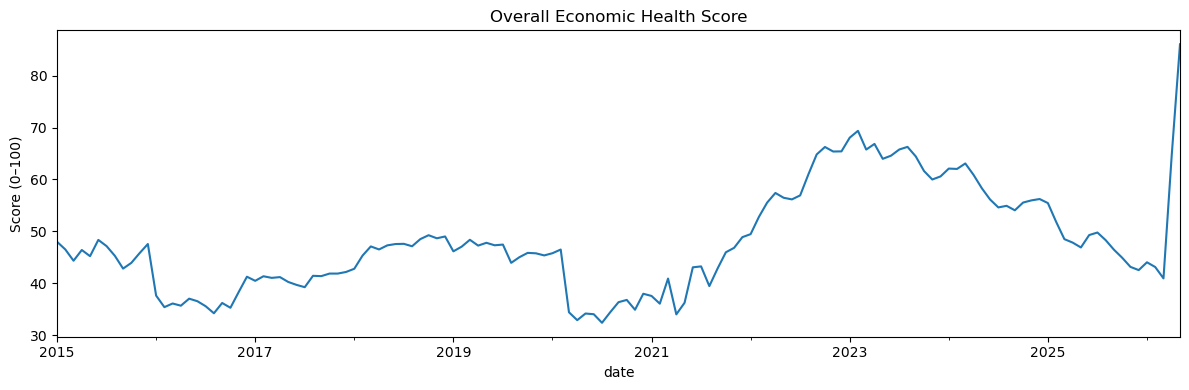

In [ ]:
import matplotlib.pyplot as plt

df["overall_health"].plot(title="Overall Economic Health Score", figsize=(12, 4))
plt.ylabel("Score (0–100)")
plt.tight_layout()
plt.show()